# Isolated Test Evaluation and Error Analysis

This notebook performs the first and only model-development evaluation against the isolated ChestMNIST test partition. It measures overall and per-finding performance, applies the frozen validation-derived thresholds, generates diagnostic visualizations and produces traceable test-prediction artifacts.

The test partition is used strictly for final evaluation. It is not used for model selection, threshold adjustment or hyperparameter tuning.

## 1. Evaluation Configuration

The isolated evaluation environment is initialized from the centralized path registry, ChestMNIST data contract and versioned inference bundle. These artifacts establish the frozen model, label order, preprocessing policy and decision thresholds.

In [1]:
from pathlib import Path
import yaml

CONFIG_ROOT = (
    Path.home()
    / "chest-xray-ai-assistant"
    / "configs"
)

PATH_CONFIG_FILE = CONFIG_ROOT / "paths.yaml"
DATASET_CONFIG_FILE = (
    CONFIG_ROOT / "chestmnist_config.yaml"
)

with PATH_CONFIG_FILE.open(
    "r",
    encoding="utf-8",
) as file:
    path_config = yaml.safe_load(file)

with DATASET_CONFIG_FILE.open(
    "r",
    encoding="utf-8",
) as file:
    dataset_config = yaml.safe_load(file)

SOLUTION_ROOT = Path(
    path_config["solution"]["root"]
)
DATA_ROOT = Path(
    path_config["data"]["root"]
)
PROCESSED_DATA_PATH = Path(
    path_config["data"]["processed"]
)
MODEL_ROOT = Path(
    path_config["data"]["models"]
)
OUTPUTS_PATH = Path(
    path_config["data"]["outputs"]
)
MLFLOW_PATH = Path(
    path_config["data"]["mlflow"]
)

MODEL_VERSION = "resnet18-chestmnist-v1"

MODEL_BUNDLE_PATH = (
    MODEL_ROOT / MODEL_VERSION
)
MODEL_WEIGHTS_FILE = (
    MODEL_BUNDLE_PATH
    / "model_state_dict.pt"
)
MODEL_METADATA_FILE = (
    MODEL_BUNDLE_PATH
    / "model_metadata.yaml"
)

with MODEL_METADATA_FILE.open(
    "r",
    encoding="utf-8",
) as file:
    model_metadata = yaml.safe_load(file)

dataset_settings = dataset_config["dataset"]
preprocessing_settings = dataset_config[
    "preprocessing"
]

DATASET_FLAG = dataset_settings["flag"]
IMAGE_SIZE = int(dataset_settings["image_size"])
NUM_LABELS = len(dataset_settings["labels"])

MEMMAP_DATA_PATH = (
    PROCESSED_DATA_PATH
    / f"{DATASET_FLAG}_{IMAGE_SIZE}_memmap"
)

print("EVALUATION CONFIGURATION")
print("-" * 100)
print(f"{'Model version':<28}: {MODEL_VERSION}")
print(f"{'Model weights':<28}: {MODEL_WEIGHTS_FILE}")
print(f"{'Model metadata':<28}: {MODEL_METADATA_FILE}")
print(f"{'Test data path':<28}: {MEMMAP_DATA_PATH}")
print(f"{'Image resolution':<28}: {IMAGE_SIZE} × {IMAGE_SIZE}")
print(f"{'Output labels':<28}: {NUM_LABELS}")
print(f"{'MLflow run ID':<28}: {model_metadata['lineage']['mlflow_run_id']}")

EVALUATION CONFIGURATION
----------------------------------------------------------------------------------------------------
Model version               : resnet18-chestmnist-v1
Model weights               : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/models/resnet18-chestmnist-v1/model_state_dict.pt
Model metadata              : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/models/resnet18-chestmnist-v1/model_metadata.yaml
Test data path              : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/processed/chestmnist_224_memmap
Image resolution            : 224 × 224
Output labels               : 14
MLflow run ID               : 089ff35f4898430784d2ce61121cfb0f


### 1.1 Frozen Inference Contract

The versioned model metadata defines the immutable output-label order, sigmoid activation and finding-specific decision thresholds used during isolated test evaluation.

In [2]:
import numpy as np

LABEL_MAP = {
    int(label_id): label_name
    for label_id, label_name
    in model_metadata[
        "output_contract"
    ]["labels"].items()
}

threshold_mapping = model_metadata[
    "output_contract"
]["thresholds"]

FROZEN_THRESHOLDS = np.array(
    [
        threshold_mapping[
            LABEL_MAP[label_id]
        ]
        for label_id in range(NUM_LABELS)
    ],
    dtype=np.float32,
)

threshold_contract_valid = (
    len(FROZEN_THRESHOLDS) == NUM_LABELS
    and np.isfinite(FROZEN_THRESHOLDS).all()
    and (FROZEN_THRESHOLDS > 0).all()
    and (FROZEN_THRESHOLDS < 1).all()
)

print("FROZEN INFERENCE CONTRACT")
print("-" * 100)
print(f"{'Registered labels':<30}: {len(LABEL_MAP)}")
print(f"{'Activation':<30}: {model_metadata['output_contract']['activation']}")
print(f"{'Minimum threshold':<30}: {FROZEN_THRESHOLDS.min():.4f}")
print(f"{'Maximum threshold':<30}: {FROZEN_THRESHOLDS.max():.4f}")
print(f"{'Threshold contract valid':<30}: {threshold_contract_valid}")
print(f"{'Checkpoint epoch':<30}: {model_metadata['model']['checkpoint_epoch']}")

FROZEN INFERENCE CONTRACT
----------------------------------------------------------------------------------------------------
Registered labels             : 14
Activation                    : sigmoid
Minimum threshold             : 0.5977
Maximum threshold             : 0.8789
Threshold contract valid      : True
Checkpoint epoch              : 2


### 1.2 Evaluation Runtime Initialization

The evaluation kernel is connected to the approved artifact locations and configured for deterministic GPU inference.

In [3]:
import os
import random
import torch

RANDOM_SEED = 42

runtime_routes = {
    "HF_HOME": path_config["cache"]["huggingface"],
    "TORCH_HOME": path_config["cache"]["torch"],
    "MLFLOW_TRACKING_URI": MLFLOW_PATH.as_uri(),
    "TOKENIZERS_PARALLELISM": "false",
}

for variable_name, variable_value in runtime_routes.items():
    os.environ[variable_name] = variable_value

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda:0"
    if torch.cuda.is_available()
    else "cpu"
)

autocast_dtype = torch.bfloat16

print("EVALUATION RUNTIME")
print("-" * 100)
print(f"{'Execution device':<28}: {device}")
print(f"{'Random seed':<28}: {RANDOM_SEED}")
print(f"{'Mixed precision':<28}: {autocast_dtype}")
print(f"{'MLflow tracking URI':<28}: {runtime_routes['MLFLOW_TRACKING_URI']}")

EVALUATION RUNTIME
----------------------------------------------------------------------------------------------------
Execution device            : cuda:0
Random seed                 : 42
Mixed precision             : torch.bfloat16
MLflow tracking URI         : file:///home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/mlflow


## 2. Isolated Test Input Pipeline

### 2.1 Deterministic Test Transformation

The isolated test partition receives the same RGB conversion and normalization used during validation. Random augmentation is excluded to guarantee deterministic predictions.

In [4]:
from torchvision import transforms

normalization_config = model_metadata[
    "input_contract"
]["normalization"]

test_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            mean=normalization_config["mean"],
            std=normalization_config[
                "standard_deviation"
            ],
        ),
    ]
)

print("DETERMINISTIC TEST TRANSFORMATION")
print("-" * 100)
print(f"{'Transformation operations':<30}: {len(test_transform.transforms)}")
print(f"{'Grayscale-to-RGB':<30}: {model_metadata['input_contract']['grayscale_to_rgb']}")
print(f"{'Input resolution':<30}: {IMAGE_SIZE} × {IMAGE_SIZE}")

DETERMINISTIC TEST TRANSFORMATION
----------------------------------------------------------------------------------------------------
Transformation operations     : 2
Grayscale-to-RGB              : True
Input resolution              : 224 × 224


### 2.2 Memory-Mapped Test Dataset Interface

A read-only PyTorch dataset streams individual test images from native NumPy arrays. The interface prevents full-partition memory loading and preserves source indices for traceable evaluation.

In [5]:
from PIL import Image
from torch.utils.data import Dataset

class ChestMNISTMemmapDataset(Dataset):
    """Read-only memory-mapped ChestMNIST dataset."""

    valid_splits = {"train", "val", "test"}

    def __init__(
        self,
        data_root,
        split,
        transform=None,
    ):
        if split not in self.valid_splits:
            raise ValueError(
                f"Unsupported split: {split}"
            )

        self.data_root = Path(data_root)
        self.split = split
        self.transform = transform

        self.images = np.load(
            self.data_root
            / f"{split}_images.npy",
            mmap_mode="r",
            allow_pickle=False,
        )
        self.labels = np.load(
            self.data_root
            / f"{split}_labels.npy",
            mmap_mode="r",
            allow_pickle=False,
        )

        if len(self.images) != len(self.labels):
            raise ValueError(
                f"Image-label count mismatch for {split}"
            )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = Image.fromarray(
            self.images[index],
            mode="L",
        ).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        target = torch.tensor(
            self.labels[index],
            dtype=torch.float32,
        )

        return image, target, int(index)


print("Memory-mapped test dataset interface created.")

Memory-mapped test dataset interface created.


### 2.3 Test Dataset and Batch Loader

The untouched test partition is initialized for deterministic inference. Sequential source indices are preserved, and the batch size is increased for efficient GPU-only evaluation.

In [6]:
from torch.utils.data import DataLoader

TEST_BATCH_SIZE = 256
TEST_NUM_WORKERS = 4

test_dataset = ChestMNISTMemmapDataset(
    data_root=MEMMAP_DATA_PATH,
    split="test",
    transform=test_transform,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    num_workers=TEST_NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
)

sample_image, sample_target, sample_index = (
    test_dataset[0]
)

resident_pages = int(
    Path("/proc/self/statm")
    .read_text()
    .split()[1]
)
process_rss_gib = (
    resident_pages
    * os.sysconf("SC_PAGE_SIZE")
    / (1024 ** 3)
)

print("ISOLATED TEST DATA LOADER")
print("-" * 100)
print(f"{'Test records':<30}: {len(test_dataset):,}")
print(f"{'Test batches':<30}: {len(test_loader):,}")
print(f"{'Batch size':<30}: {TEST_BATCH_SIZE}")
print(f"{'Worker processes':<30}: {TEST_NUM_WORKERS}")
print(f"{'Sample image shape':<30}: {tuple(sample_image.shape)}")
print(f"{'Sample target shape':<30}: {tuple(sample_target.shape)}")
print(f"{'First source index':<30}: {sample_index}")
print(f"{'Process resident memory':<30}: {process_rss_gib:.2f} GiB")

del sample_image
del sample_target

ISOLATED TEST DATA LOADER
----------------------------------------------------------------------------------------------------
Test records                  : 22,433
Test batches                  : 88
Batch size                    : 256
Worker processes              : 4
Sample image shape            : (3, 224, 224)
Sample target shape           : (14,)
First source index            : 0
Process resident memory       : 0.52 GiB


## 3. Versioned Model Restoration

### 3.1 Inference Model Loading

The selected model architecture is reconstructed and loaded from the controlled inference bundle. Strict state-dictionary validation ensures that the deployed architecture exactly matches the trained checkpoint.

In [7]:
import torch.nn as nn
from torchvision.models import resnet18

CLASSIFIER_DROPOUT = 0.20

model = resnet18(weights=None)

classifier_input_features = (
    model.fc.in_features
)

model.fc = nn.Sequential(
    nn.Dropout(
        p=CLASSIFIER_DROPOUT,
    ),
    nn.Linear(
        classifier_input_features,
        NUM_LABELS,
    ),
)

model_state_dict = torch.load(
    MODEL_WEIGHTS_FILE,
    map_location="cpu",
    weights_only=True,
)

load_result = model.load_state_dict(
    model_state_dict,
    strict=True,
)

model = model.to(device)
model.eval()

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print("VERSIONED MODEL RESTORATION")
print("-" * 100)
print(f"{'Architecture':<30}: ResNet-18")
print(f"{'Model version':<30}: {MODEL_VERSION}")
print(f"{'Total parameters':<30}: {total_parameters:,}")
print(f"{'Missing state keys':<30}: {len(load_result.missing_keys)}")
print(f"{'Unexpected state keys':<30}: {len(load_result.unexpected_keys)}")
print(f"{'Execution device':<30}: {next(model.parameters()).device}")
print(f"{'Evaluation mode':<30}: {not model.training}")

del model_state_dict

VERSIONED MODEL RESTORATION
----------------------------------------------------------------------------------------------------
Architecture                  : ResNet-18
Model version                 : resnet18-chestmnist-v1
Total parameters              : 11,183,694
Missing state keys            : 0
Unexpected state keys         : 0
Execution device              : cuda:0
Evaluation mode               : True


### 3.2 Isolated Inference Function

A reusable inference function aggregates sigmoid probabilities for the complete isolated test partition while preserving source-index alignment and operational performance measurements.

In [8]:
import time
from tqdm.auto import tqdm

def run_isolated_inference(
    model,
    data_loader,
    device,
    autocast_dtype,
):
    model.eval()

    target_batches = []
    probability_batches = []
    index_batches = []

    processed_samples = 0

    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    inference_start = time.perf_counter()

    progress_bar = tqdm(
        data_loader,
        desc="Isolated test inference",
        leave=False,
    )

    with torch.no_grad():
        for images, targets, indices in progress_bar:
            images = images.to(
                device,
                non_blocking=True,
            )

            with torch.amp.autocast(
                device_type="cuda",
                dtype=autocast_dtype,
            ):
                logits = model(images)

            probabilities = torch.sigmoid(
                logits
            )

            target_batches.append(
                targets.numpy()
            )
            probability_batches.append(
                probabilities.float().cpu().numpy()
            )
            index_batches.append(
                indices.numpy()
            )

            processed_samples += images.size(0)

    torch.cuda.synchronize()
    elapsed_seconds = (
        time.perf_counter() - inference_start
    )

    return {
        "targets": np.concatenate(
            target_batches,
            axis=0,
        ),
        "probabilities": np.concatenate(
            probability_batches,
            axis=0,
        ),
        "indices": np.concatenate(
            index_batches,
            axis=0,
        ),
        "samples": processed_samples,
        "duration_seconds": elapsed_seconds,
        "samples_per_second": (
            processed_samples / elapsed_seconds
        ),
        "milliseconds_per_image": (
            elapsed_seconds
            / processed_samples
            * 1000
        ),
        "peak_gpu_memory_gib": (
            torch.cuda.max_memory_allocated()
            / (1024 ** 3)
        ),
    }


print("Isolated inference function created.")

Isolated inference function created.


### 3.3 Complete Test Inference

The frozen model is executed against the complete isolated test partition. Output shape, index alignment and probability bounds are validated before any performance metrics are calculated.

In [9]:
test_inference = run_isolated_inference(
    model=model,
    data_loader=test_loader,
    device=device,
    autocast_dtype=autocast_dtype,
)

test_targets = test_inference["targets"]
test_probabilities = test_inference[
    "probabilities"
]
test_indices = test_inference["indices"]

inference_integrity = (
    test_targets.shape
    == (
        len(test_dataset),
        NUM_LABELS,
    )
    and test_probabilities.shape
    == test_targets.shape
    and np.array_equal(
        test_indices,
        np.arange(len(test_dataset)),
    )
    and np.isfinite(
        test_probabilities
    ).all()
    and (test_probabilities >= 0).all()
    and (test_probabilities <= 1).all()
)

print("COMPLETE TEST INFERENCE")
print("-" * 100)
print(f"{'Processed images':<32}: {test_inference['samples']:,}")
print(f"{'Target matrix':<32}: {test_targets.shape}")
print(f"{'Probability matrix':<32}: {test_probabilities.shape}")
print(f"{'Index range':<32}: {test_indices.min()}–{test_indices.max()}")
print(
    f"{'Inference duration':<32}: "
    f"{test_inference['duration_seconds']:.2f} seconds"
)
print(
    f"{'Inference throughput':<32}: "
    f"{test_inference['samples_per_second']:.2f} images/second"
)
print(
    f"{'Average time per image':<32}: "
    f"{test_inference['milliseconds_per_image']:.3f} ms"
)
print(
    f"{'Peak GPU memory':<32}: "
    f"{test_inference['peak_gpu_memory_gib']:.2f} GiB"
)
print(f"{'Inference integrity':<32}: {'PASS' if inference_integrity else 'FAIL'}")

Isolated test inference:   0%|          | 0/88 [00:00<?, ?it/s]

COMPLETE TEST INFERENCE
----------------------------------------------------------------------------------------------------
Processed images                : 22,433
Target matrix                   : (22433, 14)
Probability matrix              : (22433, 14)
Index range                     : 0–22432
Inference duration              : 14.43 seconds
Inference throughput            : 1554.43 images/second
Average time per image          : 0.643 ms
Peak GPU memory                 : 1.22 GiB
Inference integrity             : PASS


## 4. Final Test Performance

### 4.1 Overall Multilabel Metrics

Final performance is measured using threshold-independent ranking metrics and threshold-dependent classification metrics. Macro metrics weight every finding equally, while micro metrics summarize performance across all label decisions.

In [10]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    hamming_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)

test_predictions = (
    test_probabilities
    >= FROZEN_THRESHOLDS
).astype(np.uint8)

test_metrics = {
    "macro_roc_auc": float(
        roc_auc_score(
            test_targets,
            test_probabilities,
            average="macro",
        )
    ),
    "micro_roc_auc": float(
        roc_auc_score(
            test_targets,
            test_probabilities,
            average="micro",
        )
    ),
    "macro_average_precision": float(
        average_precision_score(
            test_targets,
            test_probabilities,
            average="macro",
        )
    ),
    "micro_average_precision": float(
        average_precision_score(
            test_targets,
            test_probabilities,
            average="micro",
        )
    ),
    "macro_precision": float(
        precision_score(
            test_targets,
            test_predictions,
            average="macro",
            zero_division=0,
        )
    ),
    "micro_precision": float(
        precision_score(
            test_targets,
            test_predictions,
            average="micro",
            zero_division=0,
        )
    ),
    "macro_recall": float(
        recall_score(
            test_targets,
            test_predictions,
            average="macro",
            zero_division=0,
        )
    ),
    "micro_recall": float(
        recall_score(
            test_targets,
            test_predictions,
            average="micro",
            zero_division=0,
        )
    ),
    "macro_f1": float(
        f1_score(
            test_targets,
            test_predictions,
            average="macro",
            zero_division=0,
        )
    ),
    "micro_f1": float(
        f1_score(
            test_targets,
            test_predictions,
            average="micro",
            zero_division=0,
        )
    ),
    "hamming_loss": float(
        hamming_loss(
            test_targets,
            test_predictions,
        )
    ),
    "subset_accuracy": float(
        accuracy_score(
            test_targets,
            test_predictions,
        )
    ),
}

print("FINAL TEST METRICS")
print("-" * 100)

for metric_name, metric_value in test_metrics.items():
    print(
        f"{metric_name.replace('_', ' ').title():<34}: "
        f"{metric_value:.4f}"
    )

FINAL TEST METRICS
----------------------------------------------------------------------------------------------------
Macro Roc Auc                     : 0.8175
Micro Roc Auc                     : 0.8226
Macro Average Precision           : 0.2216
Micro Average Precision           : 0.2111
Macro Precision                   : 0.2241
Micro Precision                   : 0.2615
Macro Recall                      : 0.4153
Micro Recall                      : 0.4821
Macro F1                          : 0.2816
Micro F1                          : 0.3391
Hamming Loss                      : 0.0988
Subset Accuracy                   : 0.3642


### 4.2 Per-Finding Test Metrics

Performance is calculated independently for every target finding using its frozen decision threshold. The analysis includes prevalence, ROC-AUC, average precision, precision, recall, specificity, F1-score and confusion-matrix counts.

In [11]:
import pandas as pd
from sklearn.metrics import confusion_matrix

per_finding_records = []

for label_id in range(NUM_LABELS):
    finding_targets = test_targets[:, label_id]
    finding_probabilities = (
        test_probabilities[:, label_id]
    )
    finding_predictions = (
        test_predictions[:, label_id]
    )

    true_negative, false_positive, false_negative, true_positive = (
        confusion_matrix(
            finding_targets,
            finding_predictions,
            labels=[0, 1],
        ).ravel()
    )

    specificity = (
        true_negative
        / (true_negative + false_positive)
    )

    per_finding_records.append(
        {
            "Label ID": label_id,
            "Finding": LABEL_MAP[label_id],
            "Test positives": int(
                finding_targets.sum()
            ),
            "Prevalence (%)": (
                finding_targets.mean() * 100
            ),
            "Threshold": float(
                FROZEN_THRESHOLDS[label_id]
            ),
            "ROC-AUC": roc_auc_score(
                finding_targets,
                finding_probabilities,
            ),
            "Average precision": (
                average_precision_score(
                    finding_targets,
                    finding_probabilities,
                )
            ),
            "Precision": precision_score(
                finding_targets,
                finding_predictions,
                zero_division=0,
            ),
            "Recall": recall_score(
                finding_targets,
                finding_predictions,
                zero_division=0,
            ),
            "Specificity": specificity,
            "F1-score": f1_score(
                finding_targets,
                finding_predictions,
                zero_division=0,
            ),
            "True positive": int(true_positive),
            "False positive": int(false_positive),
            "False negative": int(false_negative),
            "True negative": int(true_negative),
        }
    )

per_finding_metrics_df = pd.DataFrame(
    per_finding_records
)

display(
    per_finding_metrics_df.style
    .format(
        {
            "Test positives": "{:,}",
            "Prevalence (%)": "{:.2f}",
            "Threshold": "{:.4f}",
            "ROC-AUC": "{:.4f}",
            "Average precision": "{:.4f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "Specificity": "{:.4f}",
            "F1-score": "{:.4f}",
            "True positive": "{:,}",
            "False positive": "{:,}",
            "False negative": "{:,}",
            "True negative": "{:,}",
        }
    )
    .hide(axis="index")
)

Label ID,Finding,Test positives,Prevalence (%),Threshold,ROC-AUC,Average precision,Precision,Recall,Specificity,F1-score,True positive,False positive,False negative,True negative
0,atelectasis,"2,420",10.79,0.6797,0.7914,0.2944,0.2821,0.5260,0.8382,0.3673,"1,273","3,239","1,147","16,774"
1,cardiomegaly,582,2.59,0.8438,0.9046,0.2723,0.2659,0.5017,0.9631,0.3476,292,806,290,"21,045"
2,effusion,"2,754",12.28,0.6758,0.8687,0.4900,0.4063,0.6972,0.8574,0.5134,"1,920","2,806",834,"16,873"
3,infiltration,"3,938",17.55,0.5977,0.6944,0.3228,0.3086,0.5373,0.7437,0.3920,"2,116","4,741","1,822","13,754"
4,mass,"1,133",5.05,0.8672,0.7853,0.2208,0.3109,0.2816,0.9668,0.2955,319,707,814,"20,593"
5,nodule,"1,335",5.95,0.8125,0.7091,0.1835,0.2092,0.2816,0.9326,0.2401,376,"1,421",959,"19,677"
6,pneumonia,242,1.08,0.7695,0.7432,0.0323,0.0376,0.2273,0.9366,0.0646,55,"1,407",187,"20,784"
7,pneumothorax,"1,089",4.85,0.8281,0.8499,0.2646,0.2957,0.4564,0.9445,0.3588,497,"1,184",592,"20,160"
8,consolidation,957,4.27,0.7461,0.7953,0.1378,0.1445,0.4336,0.8856,0.2168,415,"2,456",542,"19,020"
9,edema,413,1.84,0.8789,0.8799,0.1293,0.1056,0.4770,0.9242,0.1729,197,"1,669",216,"20,351"


### 4.3 Per-Finding Performance Comparison

ROC-AUC, average precision and calibrated F1-score are compared across all findings to expose differences between ranking quality and thresholded classification performance.

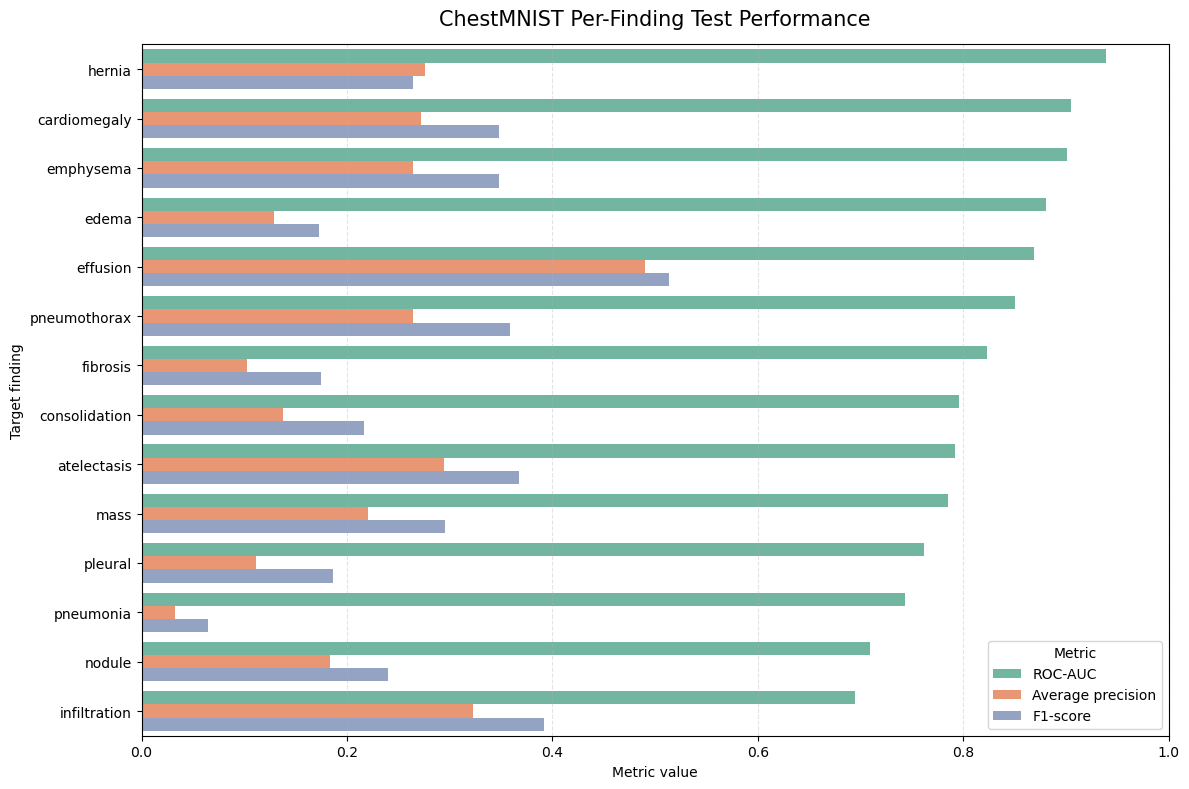

Chart saved: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/outputs/charts/test_per_finding_performance.png


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

evaluation_charts_path = (
    OUTPUTS_PATH / "charts"
)
evaluation_charts_path.mkdir(
    parents=True,
    exist_ok=True,
)

metric_comparison_data = (
    per_finding_metrics_df[
        [
            "Finding",
            "ROC-AUC",
            "Average precision",
            "F1-score",
        ]
    ]
    .melt(
        id_vars="Finding",
        var_name="Metric",
        value_name="Score",
    )
)

finding_order = (
    per_finding_metrics_df
    .sort_values(
        "ROC-AUC",
        ascending=False,
    )["Finding"]
    .tolist()
)

plt.figure(figsize=(12, 8))

axis = sns.barplot(
    data=metric_comparison_data,
    x="Score",
    y="Finding",
    hue="Metric",
    order=finding_order,
    palette="Set2",
)

axis.set_title(
    "ChestMNIST Per-Finding Test Performance",
    fontsize=15,
    pad=14,
)
axis.set_xlabel("Metric value")
axis.set_ylabel("Target finding")
axis.set_xlim(0, 1)
axis.grid(axis="x", linestyle="--", alpha=0.35)
axis.legend(
    title="Metric",
    loc="lower right",
)

plt.tight_layout()

finding_performance_chart = (
    evaluation_charts_path
    / "test_per_finding_performance.png"
)

plt.savefig(
    finding_performance_chart,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Chart saved: {finding_performance_chart}")

### 4.4 ROC and Precision-Recall Curves

Per-finding ROC and precision-recall curves are generated from the isolated test probabilities. Precision-recall curves are particularly important because most findings have low positive prevalence.

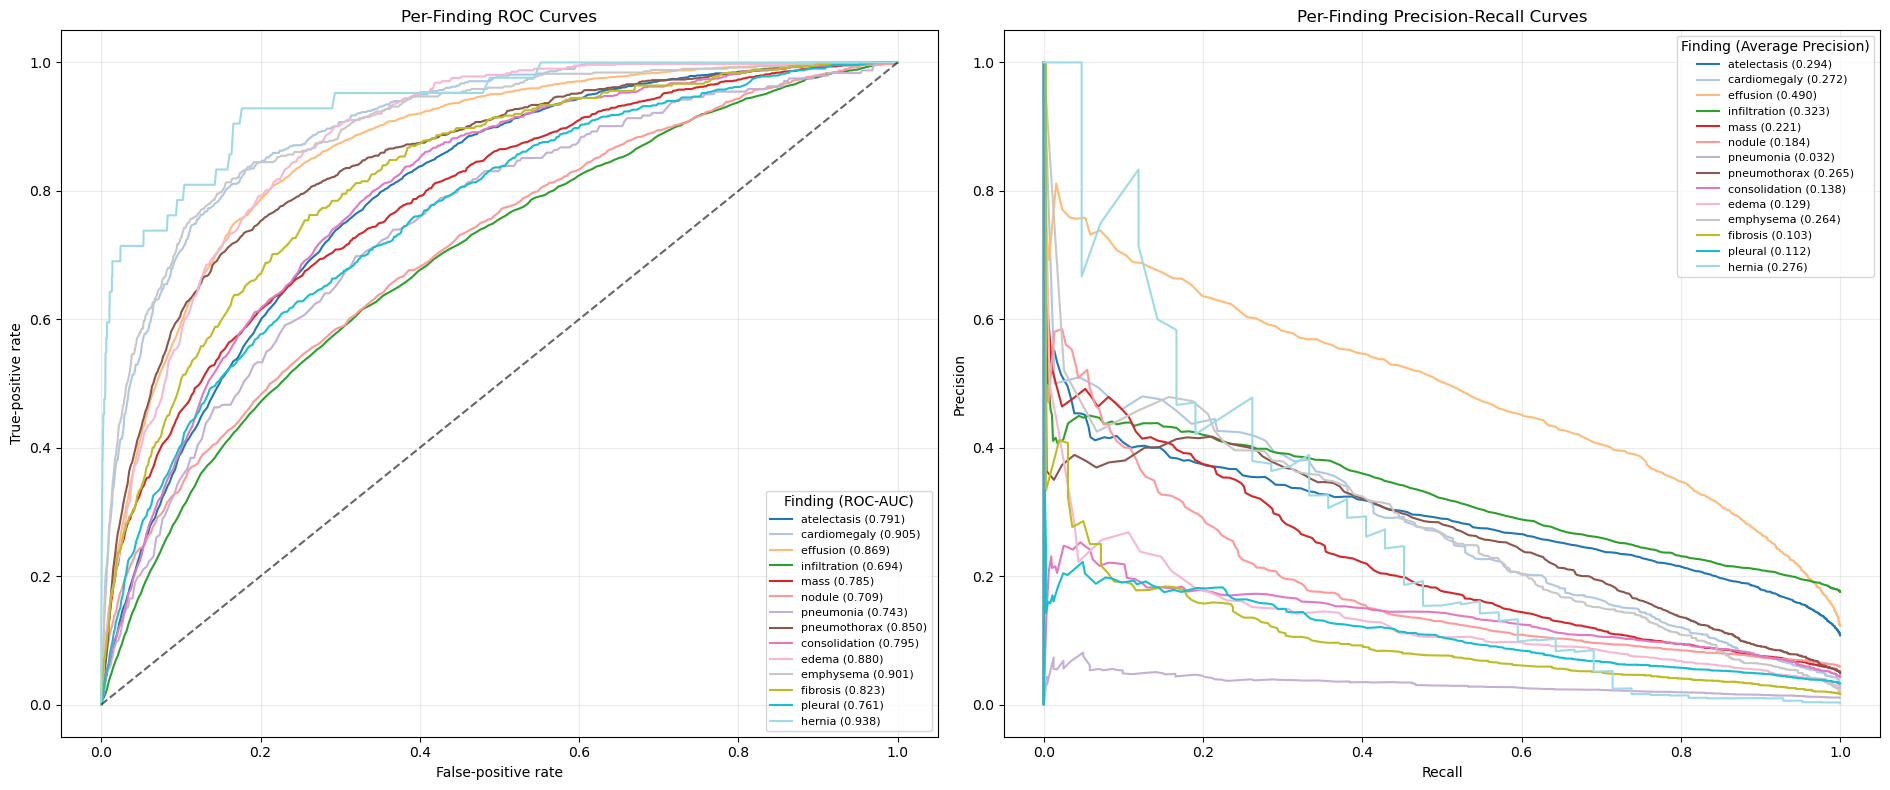

Chart saved: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/outputs/charts/test_roc_precision_recall_curves.png


In [13]:
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(19, 8),
)

color_palette = plt.cm.tab20(
    np.linspace(0, 1, NUM_LABELS)
)

for label_id, color in enumerate(color_palette):
    finding_name = LABEL_MAP[label_id]
    finding_targets = test_targets[:, label_id]
    finding_probabilities = (
        test_probabilities[:, label_id]
    )

    false_positive_rate, true_positive_rate, _ = (
        roc_curve(
            finding_targets,
            finding_probabilities,
        )
    )

    precision_values, recall_values, _ = (
        precision_recall_curve(
            finding_targets,
            finding_probabilities,
        )
    )

    finding_auc = per_finding_metrics_df.loc[
        label_id,
        "ROC-AUC",
    ]
    finding_ap = per_finding_metrics_df.loc[
        label_id,
        "Average precision",
    ]

    axes[0].plot(
        false_positive_rate,
        true_positive_rate,
        color=color,
        linewidth=1.5,
        label=(
            f"{finding_name} "
            f"({finding_auc:.3f})"
        ),
    )

    axes[1].plot(
        recall_values,
        precision_values,
        color=color,
        linewidth=1.5,
        label=(
            f"{finding_name} "
            f"({finding_ap:.3f})"
        ),
    )

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    alpha=0.6,
)
axes[0].set_title("Per-Finding ROC Curves")
axes[0].set_xlabel("False-positive rate")
axes[0].set_ylabel("True-positive rate")
axes[0].grid(alpha=0.25)
axes[0].legend(
    title="Finding (ROC-AUC)",
    fontsize=8,
    loc="lower right",
)

axes[1].set_title(
    "Per-Finding Precision-Recall Curves"
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].grid(alpha=0.25)
axes[1].legend(
    title="Finding (Average Precision)",
    fontsize=8,
    loc="upper right",
)

plt.tight_layout()

ranking_curves_chart = (
    evaluation_charts_path
    / "test_roc_precision_recall_curves.png"
)

plt.savefig(
    ranking_curves_chart,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Chart saved: {ranking_curves_chart}")

### 4.5 Per-Finding Confusion Matrices

Row-normalized confusion matrices summarize per-finding specificity and sensitivity at the frozen thresholds. Normalization prevents the large negative class from visually obscuring positive-case performance.

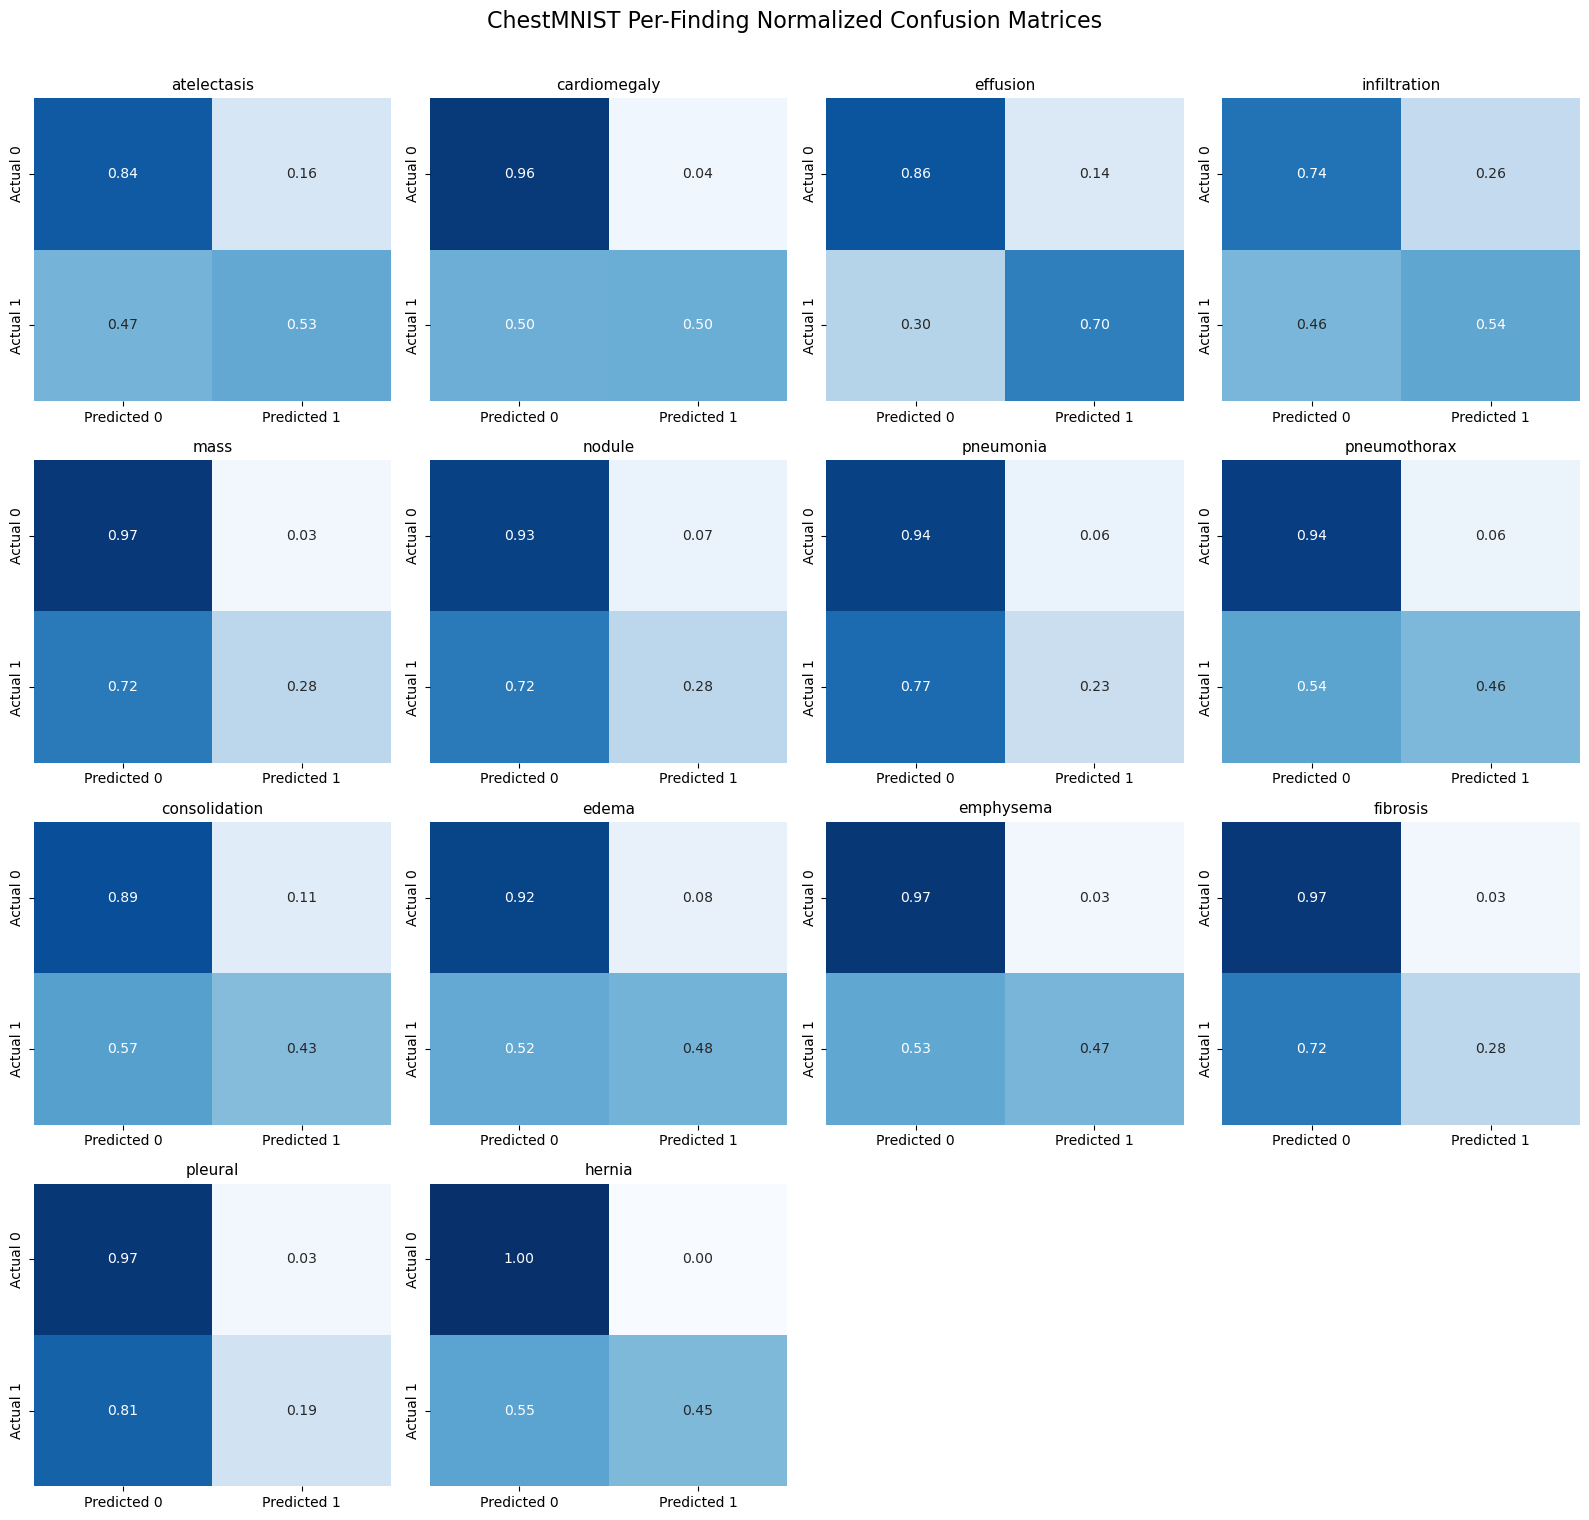

Chart saved: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/outputs/charts/test_normalized_confusion_matrices.png


In [14]:
figure, axes = plt.subplots(
    4,
    4,
    figsize=(16, 15),
)

axes = axes.flatten()

for label_id in range(NUM_LABELS):
    normalized_matrix = confusion_matrix(
        test_targets[:, label_id],
        test_predictions[:, label_id],
        labels=[0, 1],
        normalize="true",
    )

    sns.heatmap(
        normalized_matrix,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        cbar=False,
        xticklabels=[
            "Predicted 0",
            "Predicted 1",
        ],
        yticklabels=[
            "Actual 0",
            "Actual 1",
        ],
        ax=axes[label_id],
    )

    axes[label_id].set_title(
        LABEL_MAP[label_id],
        fontsize=11,
    )
    axes[label_id].set_xlabel("")
    axes[label_id].set_ylabel("")

for unused_axis in axes[NUM_LABELS:]:
    unused_axis.axis("off")

figure.suptitle(
    "ChestMNIST Per-Finding Normalized Confusion Matrices",
    fontsize=16,
    y=1.01,
)

plt.tight_layout()

confusion_matrix_chart = (
    evaluation_charts_path
    / "test_normalized_confusion_matrices.png"
)

plt.savefig(
    confusion_matrix_chart,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Chart saved: {confusion_matrix_chart}")

## 5. Error Analysis

### 5.1 Sample-Level Error Profile

Sample-level analysis measures exact prediction agreement, false alerts on images without recorded target findings, and missed detections on images containing one or more recorded findings. All rates use the relevant test population as their denominator.

In [15]:
target_cardinality = test_targets.sum(axis=1)
prediction_cardinality = test_predictions.sum(axis=1)

sample_true_positives = np.logical_and(
    test_targets == 1,
    test_predictions == 1,
).sum(axis=1)

sample_false_positives = np.logical_and(
    test_targets == 0,
    test_predictions == 1,
).sum(axis=1)

sample_false_negatives = np.logical_and(
    test_targets == 1,
    test_predictions == 0,
).sum(axis=1)

positive_image_mask = target_cardinality > 0
no_finding_image_mask = target_cardinality == 0

def create_error_record(
    measure,
    event_mask,
    population_mask,
):
    event_count = int(
        np.logical_and(
            event_mask,
            population_mask,
        ).sum()
    )
    population_count = int(population_mask.sum())

    return {
        "Measure": measure,
        "Affected images": event_count,
        "Relevant population": population_count,
        "Rate (%)": (
            100.0 * event_count / population_count
        ),
    }

sample_error_profile_df = pd.DataFrame(
    [
        create_error_record(
            "Exact fourteen-label agreement",
            np.all(
                test_targets == test_predictions,
                axis=1,
            ),
            np.ones(
                len(test_targets),
                dtype=bool,
            ),
        ),
        create_error_record(
            "At least one false-positive finding",
            sample_false_positives > 0,
            np.ones(
                len(test_targets),
                dtype=bool,
            ),
        ),
        create_error_record(
            "At least one recorded finding missed",
            sample_false_negatives > 0,
            positive_image_mask,
        ),
        create_error_record(
            "All recorded findings missed",
            sample_true_positives == 0,
            positive_image_mask,
        ),
        create_error_record(
            "False alert on no-finding image",
            prediction_cardinality > 0,
            no_finding_image_mask,
        ),
        create_error_record(
            "Correct no-finding prediction",
            prediction_cardinality == 0,
            no_finding_image_mask,
        ),
    ]
)

sample_error_profile_df.style.format(
    {
        "Affected images": "{:,}",
        "Relevant population": "{:,}",
        "Rate (%)": "{:.2f}",
    }
)

,Measure,Affected images,Relevant population,Rate (%)
0,Exact fourteen-label agreement,"8,169","22,433",36.42
1,At least one false-positive finding,"11,154","22,433",49.72
2,At least one recorded finding missed,"6,751","10,505",64.26
3,All recorded findings missed,"4,517","10,505",43.00
4,False alert on no-finding image,"4,446","11,928",37.27
5,Correct no-finding prediction,"7,482","11,928",62.73


### 5.2 Recorded and Predicted Finding Cardinality

Finding-cardinality analysis compares the number of recorded target findings per test image with the number produced by the frozen inference contract. This identifies systematic underprediction or overprediction across multilabel cases.

In [16]:
maximum_cardinality = int(
    max(
        target_cardinality.max(),
        prediction_cardinality.max(),
    )
)

cardinality_values = np.arange(
    maximum_cardinality + 1
)

recorded_counts = np.bincount(
    target_cardinality.astype(int),
    minlength=maximum_cardinality + 1,
)

predicted_counts = np.bincount(
    prediction_cardinality.astype(int),
    minlength=maximum_cardinality + 1,
)

cardinality_comparison_df = pd.DataFrame(
    {
        "Finding count": cardinality_values,
        "Recorded images": recorded_counts,
        "Recorded images (%)": (
            100.0 * recorded_counts / len(test_targets)
        ),
        "Predicted images": predicted_counts,
        "Predicted images (%)": (
            100.0 * predicted_counts / len(test_predictions)
        ),
    }
)

print(
    "Mean recorded findings per image : "
    f"{target_cardinality.mean():.3f}"
)

print(
    "Mean predicted findings per image: "
    f"{prediction_cardinality.mean():.3f}"
)

display(
    cardinality_comparison_df.style.format(
        {
            "Finding count": "{:d}",
            "Recorded images": "{:,}",
            "Recorded images (%)": "{:.2f}",
            "Predicted images": "{:,}",
            "Predicted images (%)": "{:.2f}",
        }
    )
)

Mean recorded findings per image : 0.736
Mean predicted findings per image: 1.357


,Finding count,Recorded images,Recorded images (%),Predicted images,Predicted images (%)
0,0,"11,928",53.17,"10,003",44.59
1,1,"6,259",27.90,"3,715",16.56
2,2,"2,914",12.99,"3,298",14.70
3,3,989,4.41,"2,682",11.96
4,4,275,1.23,"1,830",8.16
5,5,54,0.24,701,3.12
6,6,12,0.05,172,0.77
7,7,2,0.01,31,0.14
8,8,0,0.00,1,0.00


### 5.3 Finding-Cardinality Distribution

The distribution comparison visualizes the model’s tendency to generate more multilabel findings than are recorded in the isolated test partition.

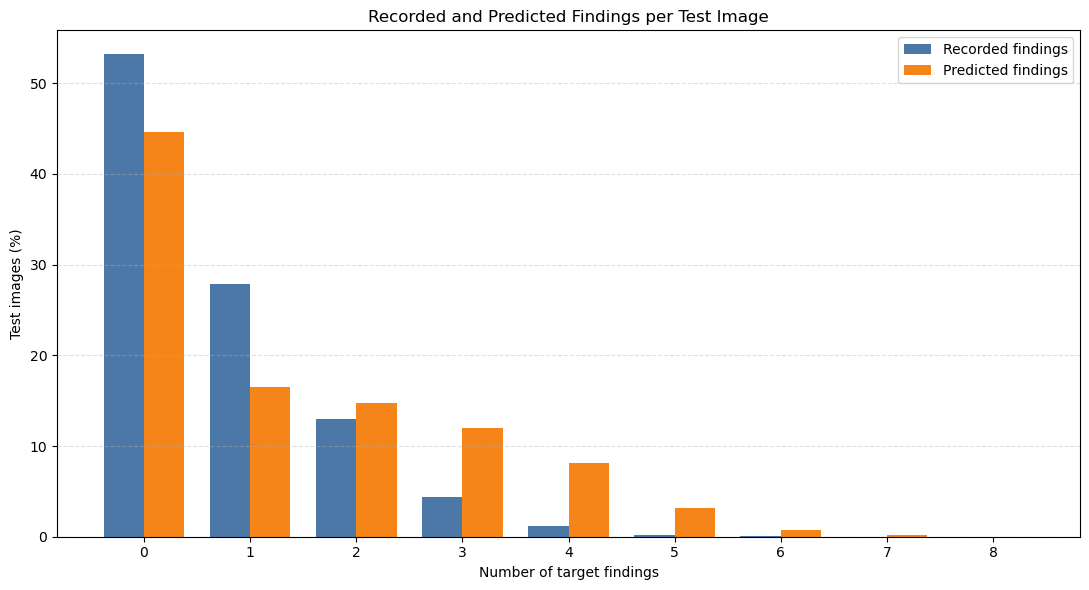

Chart saved: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/outputs/charts/test_cardinality_comparison.png


In [17]:
figure, axis = plt.subplots(
    figsize=(11, 6),
)

bar_width = 0.38
x_positions = np.arange(
    len(cardinality_comparison_df)
)

axis.bar(
    x_positions - bar_width / 2,
    cardinality_comparison_df["Recorded images (%)"],
    width=bar_width,
    label="Recorded findings",
    color="#4C78A8",
)

axis.bar(
    x_positions + bar_width / 2,
    cardinality_comparison_df["Predicted images (%)"],
    width=bar_width,
    label="Predicted findings",
    color="#F58518",
)

axis.set_title(
    "Recorded and Predicted Findings per Test Image"
)
axis.set_xlabel(
    "Number of target findings"
)
axis.set_ylabel(
    "Test images (%)"
)
axis.set_xticks(
    x_positions
)
axis.set_xticklabels(
    cardinality_comparison_df["Finding count"]
)
axis.legend()
axis.grid(
    axis="y",
    linestyle="--",
    alpha=0.4,
)

plt.tight_layout()

cardinality_chart = (
    evaluation_charts_path
    / "test_cardinality_comparison.png"
)

plt.savefig(
    cardinality_chart,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Chart saved: {cardinality_chart}")

### 5.4 Representative Prediction Cases

Representative true-positive, false-positive, and false-negative cases are registered for every target finding. Cases are selected using the highest model probability within each outcome category, while false negatives represent the closest missed detections below their frozen thresholds.

The resulting source indices provide a reproducible bridge between quantitative evaluation and subsequent visual explainability.

In [19]:
frozen_thresholds = (
    per_finding_metrics_df["Threshold"]
    .to_numpy(dtype=np.float32)
)


def select_highest_probability_case(
    outcome_mask,
    label_probabilities,
):
    candidate_positions = np.flatnonzero(
        outcome_mask
    )

    if candidate_positions.size == 0:
        return None, np.nan

    selected_position = candidate_positions[
        np.argmax(
            label_probabilities[
                candidate_positions
            ]
        )
    ]

    return (
        int(test_indices[selected_position]),
        float(label_probabilities[selected_position]),
    )


representative_case_records = []

for label_id in range(NUM_LABELS):
    label_targets = test_targets[:, label_id]
    label_predictions = test_predictions[:, label_id]
    label_probabilities = test_probabilities[:, label_id]

    true_positive_index, true_positive_probability = (
        select_highest_probability_case(
            np.logical_and(
                label_targets == 1,
                label_predictions == 1,
            ),
            label_probabilities,
        )
    )

    false_positive_index, false_positive_probability = (
        select_highest_probability_case(
            np.logical_and(
                label_targets == 0,
                label_predictions == 1,
            ),
            label_probabilities,
        )
    )

    false_negative_index, false_negative_probability = (
        select_highest_probability_case(
            np.logical_and(
                label_targets == 1,
                label_predictions == 0,
            ),
            label_probabilities,
        )
    )

    representative_case_records.append(
        {
            "Label ID": label_id,
            "Finding": LABEL_MAP[label_id],
            "Threshold": frozen_thresholds[label_id],
            "True-positive index": true_positive_index,
            "True-positive probability": true_positive_probability,
            "False-positive index": false_positive_index,
            "False-positive probability": false_positive_probability,
            "False-negative index": false_negative_index,
            "False-negative probability": false_negative_probability,
        }
    )

representative_cases_df = pd.DataFrame(
    representative_case_records
)

representative_cases_df.style.format(
    {
        "Threshold": "{:.4f}",
        "True-positive probability": "{:.4f}",
        "False-positive probability": "{:.4f}",
        "False-negative probability": "{:.4f}",
    },
    na_rep="Not available",
)

,Label ID,Finding,Threshold,True-positive index,True-positive probability,False-positive index,False-positive probability,False-negative index,False-negative probability
0,0,atelectasis,0.6797,1690,0.9727,17780,0.9727,3207,0.6758
1,1,cardiomegaly,0.8438,8392,1.0000,2216,1.0000,2170,0.8398
2,2,effusion,0.6758,16163,0.9961,5868,0.9922,1238,0.6719
3,3,infiltration,0.5977,12793,0.9141,12370,0.9180,177,0.5938
4,4,mass,0.8672,1746,1.0000,4028,1.0000,1110,0.8633
5,5,nodule,0.8125,18246,0.9922,16945,0.9961,167,0.8086
6,6,pneumonia,0.7695,22066,0.8984,4680,0.9258,2947,0.7656
7,7,pneumothorax,0.8281,2287,0.9961,1138,0.9961,8410,0.8242
8,8,consolidation,0.7461,4229,0.9258,6159,0.9492,3595,0.7422
9,9,edema,0.8789,5724,0.9961,592,0.9961,3963,0.8750


## 6. Evaluation Artifact Registration

### 6.1 Analytical Table Export

Evaluation tables are exported as versioned solution artifacts. These files preserve overall error patterns, per-finding performance, cardinality behaviour, and representative cases for reporting and explainability workflows.

In [20]:
evaluation_metrics_path = (
    evaluation_charts_path.parent
    / "metrics"
)

evaluation_metrics_path.mkdir(
    parents=True,
    exist_ok=True,
)

evaluation_table_registry = {
    "test_per_finding_metrics.csv": per_finding_metrics_df,
    "test_sample_error_profile.csv": sample_error_profile_df,
    "test_cardinality_comparison.csv": cardinality_comparison_df,
    "test_representative_cases.csv": representative_cases_df,
}

print("EVALUATION TABLE EXPORT")
print("-" * 110)

for file_name, dataframe in evaluation_table_registry.items():
    artifact_path = (
        evaluation_metrics_path
        / file_name
    )

    dataframe.to_csv(
        artifact_path,
        index=False,
    )

    print(
        f"{file_name:<36} | "
        f"Created: {artifact_path.is_file()} | "
        f"Rows: {len(dataframe):,} | "
        f"Path: {artifact_path}"
    )

EVALUATION TABLE EXPORT
--------------------------------------------------------------------------------------------------------------
test_per_finding_metrics.csv         | Created: True | Rows: 14 | Path: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/outputs/metrics/test_per_finding_metrics.csv
test_sample_error_profile.csv        | Created: True | Rows: 6 | Path: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/outputs/metrics/test_sample_error_profile.csv
test_cardinality_comparison.csv      | Created: True | Rows: 9 | Path: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/outputs/metrics/test_cardinality_comparison.csv
test_representative_cases.csv        | Created: True | Rows: 14 | Path: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/outputs/metrics/test_representative_cases.csv


### 6.2 Frozen Test Prediction Bundle

The complete isolated-test output is stored as a compressed prediction bundle containing source indices, recorded targets, sigmoid probabilities, binary predictions, and frozen thresholds. This artifact enables reproducible downstream analysis without rerunning GPU inference.

In [21]:
import json


overall_test_metrics = {
    "macro_roc_auc": float(
        roc_auc_score(
            test_targets,
            test_probabilities,
            average="macro",
        )
    ),
    "micro_roc_auc": float(
        roc_auc_score(
            test_targets,
            test_probabilities,
            average="micro",
        )
    ),
    "macro_average_precision": float(
        average_precision_score(
            test_targets,
            test_probabilities,
            average="macro",
        )
    ),
    "micro_average_precision": float(
        average_precision_score(
            test_targets,
            test_probabilities,
            average="micro",
        )
    ),
    "macro_precision": float(
        precision_score(
            test_targets,
            test_predictions,
            average="macro",
            zero_division=0,
        )
    ),
    "micro_precision": float(
        precision_score(
            test_targets,
            test_predictions,
            average="micro",
            zero_division=0,
        )
    ),
    "macro_recall": float(
        recall_score(
            test_targets,
            test_predictions,
            average="macro",
            zero_division=0,
        )
    ),
    "micro_recall": float(
        recall_score(
            test_targets,
            test_predictions,
            average="micro",
            zero_division=0,
        )
    ),
    "macro_f1": float(
        f1_score(
            test_targets,
            test_predictions,
            average="macro",
            zero_division=0,
        )
    ),
    "micro_f1": float(
        f1_score(
            test_targets,
            test_predictions,
            average="micro",
            zero_division=0,
        )
    ),
    "hamming_loss": float(
        hamming_loss(
            test_targets,
            test_predictions,
        )
    ),
    "subset_accuracy": float(
        accuracy_score(
            test_targets,
            test_predictions,
        )
    ),
}

overall_metrics_file = (
    evaluation_metrics_path
    / "test_overall_metrics.json"
)

with overall_metrics_file.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        overall_test_metrics,
        file,
        indent=2,
    )

prediction_bundle_file = (
    evaluation_metrics_path
    / "test_prediction_bundle.npz"
)

np.savez_compressed(
    prediction_bundle_file,
    source_indices=np.asarray(
        test_indices,
        dtype=np.int64,
    ),
    targets=np.asarray(
        test_targets,
        dtype=np.uint8,
    ),
    probabilities=np.asarray(
        test_probabilities,
        dtype=np.float32,
    ),
    predictions=np.asarray(
        test_predictions,
        dtype=np.uint8,
    ),
    thresholds=np.asarray(
        frozen_thresholds,
        dtype=np.float32,
    ),
)

print("FROZEN TEST ARTIFACTS")
print("-" * 110)

for artifact_path in [
    overall_metrics_file,
    prediction_bundle_file,
]:
    print(
        f"{artifact_path.name:<32} | "
        f"Created: {artifact_path.is_file()} | "
        f"Size: {artifact_path.stat().st_size / (1024 ** 2):.2f} MiB | "
        f"Path: {artifact_path}"
    )

FROZEN TEST ARTIFACTS
--------------------------------------------------------------------------------------------------------------
test_overall_metrics.json        | Created: True | Size: 0.00 MiB | Path: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/outputs/metrics/test_overall_metrics.json
test_prediction_bundle.npz       | Created: True | Size: 0.58 MiB | Path: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/outputs/metrics/test_prediction_bundle.npz


### 6.3 MLflow Evaluation Registration

Final test metrics, analytical tables, prediction outputs, and evaluation charts are attached to the originating model-development run. This preserves lineage between the selected checkpoint and its first isolated-test evaluation.

In [23]:
import mlflow
from mlflow.tracking import MlflowClient


evaluation_run_id = (
    "089ff35f4898430784d2ce61121cfb0f"
)

mlflow_client = MlflowClient(
    tracking_uri=mlflow.get_tracking_uri()
)

for metric_name, metric_value in overall_test_metrics.items():
    mlflow_client.log_metric(
        run_id=evaluation_run_id,
        key=f"test_{metric_name}",
        value=metric_value,
    )

evaluation_metric_artifacts = sorted(
    evaluation_metrics_path.glob(
        "test_*"
    )
)

evaluation_chart_artifacts = sorted(
    evaluation_charts_path.glob(
        "test_*.png"
    )
)

for artifact_path in evaluation_metric_artifacts:
    mlflow_client.log_artifact(
        run_id=evaluation_run_id,
        local_path=str(artifact_path),
        artifact_path="evaluation/metrics",
    )

for artifact_path in evaluation_chart_artifacts:
    mlflow_client.log_artifact(
        run_id=evaluation_run_id,
        local_path=str(artifact_path),
        artifact_path="evaluation/charts",
    )

mlflow_client.set_tag(
    evaluation_run_id,
    "isolated_test_evaluation",
    "completed",
)

mlflow_client.set_tag(
    evaluation_run_id,
    "evaluation_threshold_source",
    "validation_partition",
)

registered_run = mlflow_client.get_run(
    evaluation_run_id
)

print("MLFLOW EVALUATION REGISTRATION")
print("-" * 100)
print(
    f"Run ID                    : "
    f"{registered_run.info.run_id}"
)
print(
    f"Run status                : "
    f"{registered_run.info.status}"
)
print(
    f"Test metrics registered   : "
    f"{len(overall_test_metrics)}"
)
print(
    f"Metric artifacts logged   : "
    f"{len(evaluation_metric_artifacts)}"
)
print(
    f"Chart artifacts logged    : "
    f"{len(evaluation_chart_artifacts)}"
)
print(
    "Threshold source          : "
    "Validation partition"
)

MLFLOW EVALUATION REGISTRATION
----------------------------------------------------------------------------------------------------
Run ID                    : 089ff35f4898430784d2ce61121cfb0f
Run status                : FINISHED
Test metrics registered   : 12
Metric artifacts logged   : 6
Chart artifacts logged    : 4
Threshold source          : Validation partition


## 7. Isolated Test Evaluation Readiness

The evaluation stage is complete when the entire test partition has been processed exactly once, frozen thresholds remain intact, performance and error-analysis artifacts are available, and all outputs are registered against the originating model run.

In [24]:
evaluation_readiness_checks = {
    "Complete test partition evaluated": (
        len(test_indices) == 22_433
        and len(np.unique(test_indices)) == 22_433
    ),
    "Probability outputs are finite": bool(
        np.isfinite(test_probabilities).all()
    ),
    "Binary predictions are valid": bool(
        np.isin(
            test_predictions,
            [0, 1],
        ).all()
    ),
    "Fourteen frozen thresholds available": (
        frozen_thresholds.shape == (NUM_LABELS,)
    ),
    "Overall metrics artifact available": (
        overall_metrics_file.is_file()
    ),
    "Per-finding metrics available": (
        (
            evaluation_metrics_path
            / "test_per_finding_metrics.csv"
        ).is_file()
    ),
    "Sample-level error profile available": (
        (
            evaluation_metrics_path
            / "test_sample_error_profile.csv"
        ).is_file()
    ),
    "Representative case registry available": (
        (
            evaluation_metrics_path
            / "test_representative_cases.csv"
        ).is_file()
    ),
    "Frozen prediction bundle available": (
        prediction_bundle_file.is_file()
    ),
    "Evaluation charts available": (
        len(evaluation_chart_artifacts) == 4
        and all(
            path.is_file()
            for path in evaluation_chart_artifacts
        )
    ),
    "MLflow evaluation registration complete": (
        registered_run.data.tags.get(
            "isolated_test_evaluation"
        )
        == "completed"
    ),
}

print("ISOLATED TEST EVALUATION READINESS")
print("-" * 100)

for check_name, check_status in evaluation_readiness_checks.items():
    print(
        f"{check_name:<48}: "
        f"{'PASS' if check_status else 'FAIL'}"
    )

evaluation_ready = all(
    evaluation_readiness_checks.values()
)

print()
print("FINAL STATUS")
print("-" * 100)
print(
    "READY FOR VISUAL EXPLAINABILITY"
    if evaluation_ready
    else "EVALUATION REQUIRES REVIEW"
)

ISOLATED TEST EVALUATION READINESS
----------------------------------------------------------------------------------------------------
Complete test partition evaluated               : PASS
Probability outputs are finite                  : PASS
Binary predictions are valid                    : PASS
Fourteen frozen thresholds available            : PASS
Overall metrics artifact available              : PASS
Per-finding metrics available                   : PASS
Sample-level error profile available            : PASS
Representative case registry available          : PASS
Frozen prediction bundle available              : PASS
Evaluation charts available                     : PASS
MLflow evaluation registration complete         : PASS

FINAL STATUS
----------------------------------------------------------------------------------------------------
READY FOR VISUAL EXPLAINABILITY
